# Sepsis Prediction
## Msc. Data Science
### Team Members
***Team ID: ML_DS_90_07***<br>
Noanika Bharat Agarkar 86621300<br>
Guilherme Maldonado Pio Avella 28289103<br>
Héctor Daniel Ochoa Fernández 79743390

## Problem Statement
Sepsis is a condition in which the body responds improperly to an infection. The infection-fighting processes turn on the body, causing the organs to work poorly. It may progress into septic shock, where there is a dramatic drop in blood pressure that can damage the lungs, kidneys, liver and other organs. If not treated early, it can lead to death.

As such, predicting whether a patient will develop sepsis is vital for doctors to perform life saving treatment.

There are some outward physical signs a patient may be developing sepsis like:
- Fever
- Chills
- A fast heartbeat
- Shortness of breath
- Dizziness
- Extreme pain or discomfort
- Fatigue

But, is there a way to predict sepsis without waiting for these symptoms to appear? Hospitals run all kinds of tests and metrics to help monitor a patients progress throughout their stay in the facilities. Using the collected data, it could be possible to develop an early sepsis prediction model.

## Dataset
We are provided with a file for each patient, with each line depicting an hour spent at the hospital alongside the test results of each hour. The first 7 rows are vital signs, rows 8 to 33 are laboratory results and rows 34 to 37 are demographic labels and the last row is the outcome.

|No.|Header|Description|
|--|--|--|
|1|HR|Heart rate (beats per minute)|
|2|O2Sat|Pulse oximetry (%)|
|3|Temp|Temperature (deg C)|
|4|SBP|Systolic BP (mm Hg)|
|5|MAP|Mean arterial pressure (mm Hg)|
|6|DBP|Diastolic BP (mm Hg)|
|7|Resp|Respiration rate (breaths per minute)|
|8|BaseExcess|Excess bicarbonate (mmol/L)|
|9|HCO3|Bicarbonate (mmol/L)|
|10|FiO2|Fraction of inspired oxygen (%)|
|11|pH|pH|
|12|PaCO2|Partial pressure of carbon dioxide from arterial blood (mm Hg)|
|13|SaO2|Oxygen saturation from arterial blood (%)|
|14|AST|Aspartate transaminase (IU/L)|
|15|BUN|Blood urea nitrogen (mg/dL)|
|16|Alkalinephos|Alkaline phosphatase (IU/L)|
|17|Calcium|Calcium (mg/dL)|
|18|Chloride|Chloride (mmol/L)|
|19|Creatinine|(mg/dL)|
|20|Bilirubin_direct|Direct bilirubin (mg/dL)|
|21|Glucose|Serum glucose (mg/dL)|
|22|Lactate|Lactic acid (mg/dL)|
|23|Magnesium|Magnesium (mmol/dL)|
|24|Phosphate|Phosphate (mg/dL)|
|25|Potassium|Potassiam (mmol/L)|
|26|Bilirubin_total|Total bilirubin (mg/dL)|
|27|TroponinI|Troponin I (ng/mL)|
|28|Hct|Hematocrit (%)|
|29|Hgb|Hemoglobin (g/dL)|
|30|PTT|Partial thromboplastin time (seconds)|
|31|WBC|Leukocyte count (count/L)|
|32|Fibrinogen|Fibrinogen concentration (mg/dL)|
|33|Platelets|Platelet count (count/mL)|
|34|Age|Age (years)|
|35|Gender|Female (0) or male (1)|
|36|HospAdmTime|Time between hospital and ICU admission (hours since ICU admission)|
|37|ICULOS|ICU length of stay (hours since ICU admission)|
|38|SepsisLabel|If Sepsis is developed, this has a value of 1|


Here's an example of what a patient's file looks like. We can observe that the patient developed sepsis on the 6th hour of their hospitalization. 

## Methodology

In [1]:
def concat_patients(train_dir, patient_list):
    
    """
    concatenate individual patient dataframe for
    the training, valid, or other dataframes to define
    lower and upper bound of each feature.
    
    @params: train_dir: String, data folder
             patient_list: list of Strings, individual patient files
    
    @return: dataframe, concatenated training or valid data
    """
    
    # read in first patient in patient list
    p = pd.read_csv(train_dir + '/' + patient_list[0], sep = "|")
    p['patient_id'] = patient_list[0][1:7]

    for i in range(1, len(patient_list)):
        p_n = pd.read_csv(train_dir + '/' + patient_list[i], sep = "|")
        p_n['patient_id'] = patient_list[i][1:7]
        p = pd.concat([p,p_n])
    return p

def predictors_labels_allocator(df):
    
    """
    function that allocate predictors and labels
    
    @param: df: Dataframe, complete dataframe
    @return: X: Numpy Array, predictors
             y: Numpy Array, labels
    """
    col_names = df.columns
    X = np.array(df[col_names[:-2]].values)
    y = df[col_names[-2]].values
    
    return X, y

def F(beta, precision, recall):
    
    """
    Function that calculate f1, f2, and f0.5 scores.
    
    @params: beta, Float, type of f score
             precision: Float, average precision
             recall: Float, average recall
    
    @return: Float, f scores
    """
    
    return (beta*beta + 1)*precision*recall / (beta*beta*precision + recall)

In [2]:
import scipy
if scipy.__version__ != "1.11.4":
    print(scipy.__version__ )
    %pip install scipy==1.11.4

print(scipy.__version__ )


1.11.4


In [3]:
# import packages
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import numpy
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import os
import random
import dill    # save or restore notebook session
import joblib


from sklearn import linear_model, preprocessing
from sklearn.metrics import precision_recall_curve, auc, roc_curve
from sklearn.metrics import precision_score, recall_score, accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from plot_metric.functions import BinaryClassification
print(np.__version__ )

1.26.1


In [4]:
# Setting up Paths
DataPath = "./Data/"

train_dir = DataPath + 'training_setA/baseline/train_baseline/'
valid_dir = DataPath + 'training_setA/baseline/val_baseline/'
test_dir  = DataPath + 'training_setA/baseline/test_baseline/'

TRAIN_PATH = train_dir + 'data_baseline_train.parquet'
VALID_PATH = valid_dir + 'data_baseline_valid.parquet'
TEST_PATH  = test_dir + 'data_baseline_test.parquet'


In [5]:
# create a list of patient file names
tr_patients = [p for p in sorted(os.listdir(train_dir))]
vld_patients = [p for p in sorted(os.listdir(valid_dir))]
ts_patients = [p for p in sorted(os.listdir(test_dir))]

print('num training patients:', len(tr_patients))
print('num valid patients:', len(vld_patients))
print('num test patients:', len(ts_patients))

num training patients: 14237
num valid patients: 3051
num test patients: 3051


Concatenate patients into `train_df`, `valid_df`, and `test_df`.

In [6]:
try:
    if not all(os.path.exists(p) for p in [TRAIN_PATH, VALID_PATH, TEST_PATH]):
        raise FileNotFoundError("One or more parquet files missing")
    train_df = pd.read_parquet(TRAIN_PATH)
    valid_df = pd.read_parquet(VALID_PATH)
    test_df  = pd.read_parquet(TEST_PATH)
    print("Loaded data from parquet files")
except Exception as e:
    print(e)
    print("Creating new parquet files...")
    train_df = concat_patients(train_dir, tr_patients)
    valid_df = concat_patients(valid_dir, vld_patients)
    test_df  = concat_patients(test_dir,  ts_patients)
    train_df.to_parquet(TRAIN_PATH, index=False)
    valid_df.to_parquet(VALID_PATH, index=False)
    test_df.to_parquet(TEST_PATH,  index=False)
    print("Saved data to parquet files")

Loaded data from parquet files


Check missing data.

In [7]:
print('train data has missing values:', train_df.isnull().sum().sum() != 0)
print('valid data has missing values:', valid_df.isnull().sum().sum() != 0)
print('test data has missing values:', test_df.isnull().sum().sum() != 0)

train data has missing values: False
valid data has missing values: False
test data has missing values: False


# Running the models

In [8]:
# --- Results tracker (added) ---
# Collects each model's test-set metrics (for a final comparison table/chart) and stashes
# each model's fitted (model, scaler) pair so a later "live detection" demo can reuse them
# without retraining.
results = []
trained_models = {}

def record_result(model_name, yts, yhat_ts, yhat_probas, fitted_model=None, fitted_scaler=None, feature_names=None):
    precision, recall, _ = precision_recall_curve(yts, yhat_probas)
    fpr, tpr, _ = roc_curve(yts, yhat_probas)
    row = {
        'model': model_name,
        'accuracy': accuracy_score(yts, yhat_ts),
        'precision': precision_score(yts, yhat_ts),
        'recall': recall_score(yts, yhat_ts),
        'f1': F(1, precision_score(yts, yhat_ts), recall_score(yts, yhat_ts)),
        'f2': F(2, precision_score(yts, yhat_ts), recall_score(yts, yhat_ts)),
        'auroc': auc(fpr, tpr),
        'auprc': auc(recall, precision),
    }
    results.append(row)
    if fitted_model is not None:
        trained_models[model_name] = {
            'model': fitted_model,
            'scaler': fitted_scaler,
            'feature_names': feature_names or list(train_df.columns[:-2]),
        }
    return row

## Logistic Regression Classification for Sepsis
We first separate features (X) and labels (y) for all datasets. Then we fit the `LogisticRegression` model on training data.

In [9]:
Xtr, ytr = predictors_labels_allocator(train_df)
Xvld, yvld = predictors_labels_allocator(valid_df)
Xts, yts = predictors_labels_allocator(test_df)

Define scaler `StandardScaler`. Fit the scaler on training data. Obtain scaled training, valid, and test data using `transform`.

In [10]:
# define scaler
scaler = preprocessing.StandardScaler()

# fit and transform data
scaler.fit(Xtr)
Xtr = scaler.transform(Xtr)
Xvld = scaler.transform(Xvld)
Xts = scaler.transform(Xts)

Create a `LogisticRegression` object `logreg` and fit the training data.

In [11]:
logreg = linear_model.LogisticRegression(C=10, solver='saga', max_iter=1000)
#logreg = linear_model.LogisticRegression(C=10, solver='lbfgs', max_iter=1000)
logreg.fit(Xtr, ytr)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'saga'
,max_iter,1000
,multi_class,'deprecated'


### Interpreting the Weight Vector
Create a stem plot of the coefficients, W in the logistic regression model. The most significant features have larger values in the stem plot.

<StemContainer object of 3 artists>

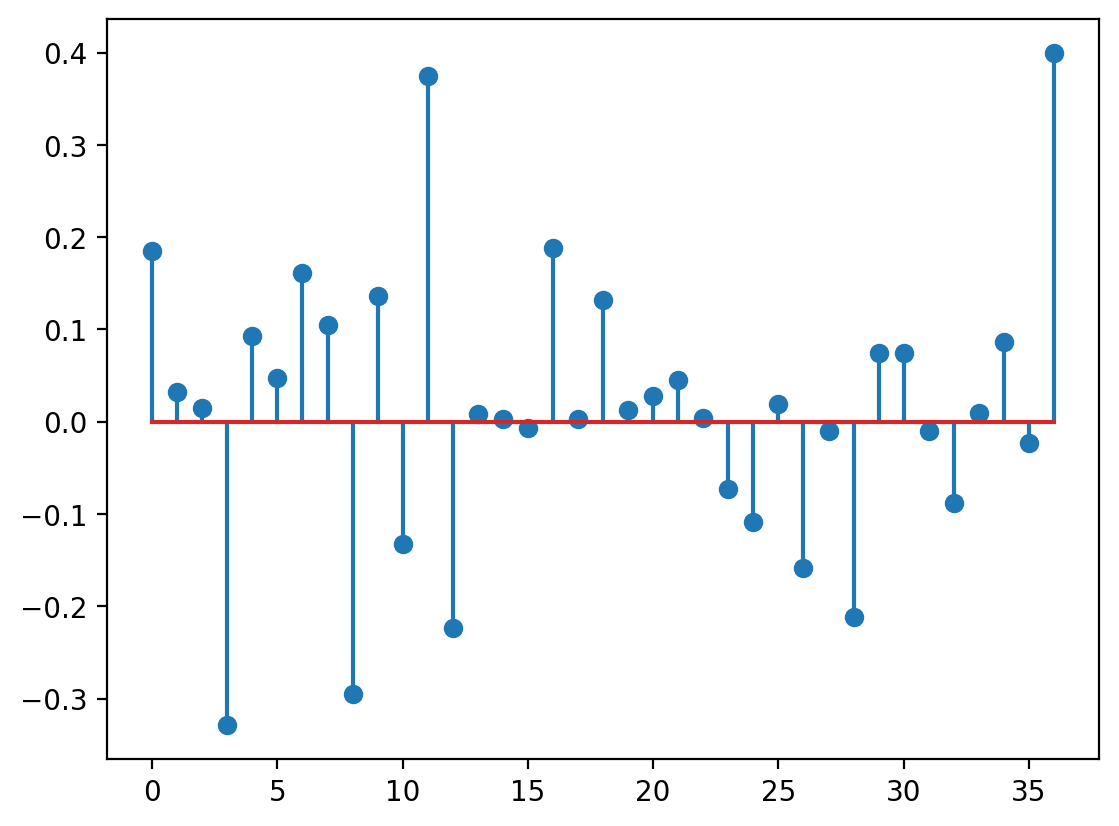

In [13]:
W = logreg.coef_.ravel()
plt.stem(W)

From the stem plot, we see four significant features that are most involved in the prediction of Sepsis.

In [14]:
ind = np.argsort(np.abs(W))
for k in range(1, 5):
    i = ind[-k]
    name = train_df.columns[:-2][i]
    print('The {0:d} most significant feature is {1:s}'.format(k, name))

The 1 most significant feature is ICULOS
The 2 most significant feature is PaCO2
The 3 most significant feature is SBP
The 4 most significant feature is HCO3


### Hyperparameter Tuning
Identify hyperparameters for tuning. Create lists of values for these hyperparameters. Use `GridSearchCV` to select the optimal model for test data prediction.

In [15]:
# create a logistic regression model
logreg = linear_model.LogisticRegression(solver='saga', max_iter=1000)
#logreg = linear_model.LogisticRegression(solver='lbfgs', max_iter=1000)

In [16]:
# create hyperparameter search space
# create regularization penalty space
penalty = ['l1', 'l2']

l1Ratio = [1,0]
# create regularization hyperparameter space
C = np.logspace(-2, 3, 10)

# create hyperparameter options
hyperparameters = dict(C=C, penalty=penalty)
#hyperparameters = dict(C=C,l1_ratio = l1Ratio)

Create `GridSearchCV` and fit the best model.

In [17]:
import joblib

CLF_PATH        = DataPath + 'tuning_clf.joblib'
BEST_MODEL_PATH = DataPath + 'tuning_best_model.joblib'

try:
    if not all(os.path.exists(p) for p in [CLF_PATH, BEST_MODEL_PATH]):
        raise FileNotFoundError("One or more joblib files missing")
    
    clf        = joblib.load(CLF_PATH)
    best_model = joblib.load(BEST_MODEL_PATH)
    print("Loaded clf and best model from joblib files")

except Exception as e:
    print(e)
    print("Error opening files, creating new...")

    clf        = GridSearchCV(logreg, hyperparameters, cv=5, verbose=0)
    best_model = clf.fit(Xtr, ytr)

    # Save each object to its own joblib file
    joblib.dump(clf,        CLF_PATH)
    joblib.dump(best_model, BEST_MODEL_PATH)
    print("Saved clf and best model to joblib files")

Loaded clf and best model from joblib files


In [18]:
print(type(clf))

<class 'sklearn.model_selection._search.GridSearchCV'>


Show the hyperparameters of the best model.

In [19]:
best_model.best_params_

{'C': 0.1, 'penalty': 'l1'}

### Test data prediction and performance
Predict test data labels using the best model.

In [20]:
# predict labels for test data
yhat_ts = best_model.predict(Xts)
# obtain the accuracy on the result
acc_ts = np.mean(yhat_ts == yts)
print('Accuracy on the test data is {0:f}'.format(acc_ts))

Accuracy on the test data is 0.976621


Plot ROC and PR curve to show model performance.

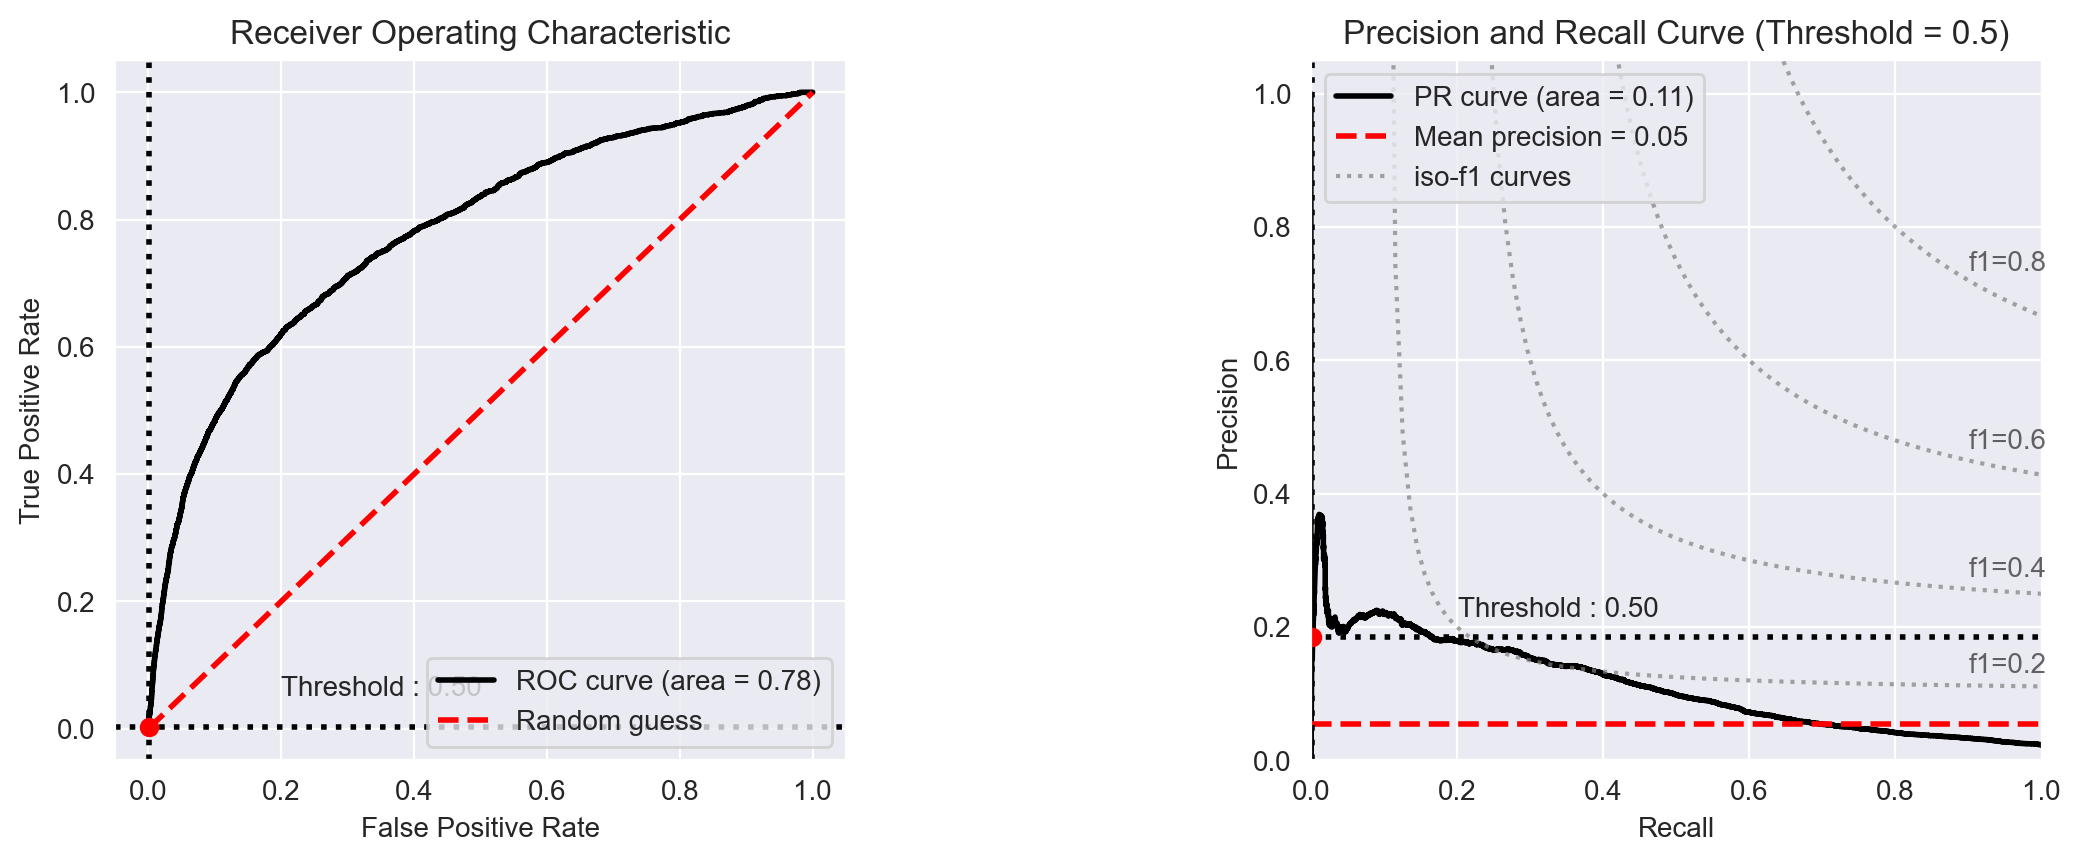

In [21]:
# prediction probability
yhat_probas = best_model.predict_proba(Xts)[:,1]

# visualisation with plot_metric
bc = BinaryClassification(yts, yhat_probas, labels=["nonSepsis", "Sepsis"])

# plots
plt.figure(figsize=(15,10))
plt.subplot2grid(shape=(2,6), loc=(0,0), colspan=2)
bc.plot_roc_curve()
plt.subplot2grid((2,6), (0,3), colspan=2)
bc.plot_precision_recall_curve()
plt.show()

Classification report.

In [22]:
# precision, recall, and f1 f2 scores
precision, recall, _ = precision_recall_curve(yts, yhat_probas)
fpr, tpr, _ = roc_curve(yts, yhat_probas)

print('f1 score {0:.4f}:'.format(F(1, np.mean(precision), np.mean(recall))))
print('f2 score {0:.4f}:'.format(F(2, np.mean(precision), np.mean(recall))))
print('precision {0:.4f}:'.format(precision_score(yts, yhat_ts)))
print('recall {0:.4f}:'.format(recall_score(yts, yhat_ts)))
print('AUPRC {0:.4f}:'.format(auc(recall, precision)))
print('AUROC {0:.4f}:'.format(auc(fpr, tpr)))
print('Acc {0:.4f}:'.format(accuracy_score(yts, yhat_ts)))

# report
bc.print_report()

f1 score 0.1019:
f2 score 0.2125:
precision 0.1923:
recall 0.0018:
AUPRC 0.1112:
AUROC 0.7774:
Acc 0.9766:
                   ________________________
                  |  Classification Report |
                   ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
              precision    recall  f1-score   support

   nonSepsis       0.98      1.00      0.99    115852
      Sepsis       0.19      0.00      0.00      2757

    accuracy                           0.98    118609
   macro avg       0.58      0.50      0.50    118609
weighted avg       0.96      0.98      0.97    118609



In [23]:
record_result('Logistic Regression', yts, yhat_ts, yhat_probas, fitted_model=best_model, fitted_scaler=scaler)

{'model': 'Logistic Regression',
 'accuracy': 0.9766206611639926,
 'precision': 0.19230769230769232,
 'recall': 0.0018135654697134566,
 'f1': 0.0035932446999640674,
 'f2': 0.0022616247512212773,
 'auroc': 0.7773810346323692,
 'auprc': 0.11120428573206646}

## Random Forest Classification for Sepsis
Separate features (X) and labels (y), then fit the model on training data.

In [24]:
Xtr,  ytr  = predictors_labels_allocator(train_df)
Xvld, yvld = predictors_labels_allocator(valid_df)
Xts,  yts  = predictors_labels_allocator(test_df)

Define and fit a `StandardScaler` on training data.

In [25]:
scaler = preprocessing.StandardScaler()
scaler.fit(Xtr)
Xtr  = scaler.transform(Xtr)
Xvld = scaler.transform(Xvld)
Xts  = scaler.transform(Xts)

Create a `Random Forest` model and fit on training data.

In [26]:
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(Xtr, ytr)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Measure validation accuracy.

In [27]:
yhat = model.predict(Xvld)
acc = np.mean(yhat == yvld)
print('Accuracy on the validation data is {0:f}'.format(acc))

Accuracy on the validation data is 0.978125


### Feature Importance

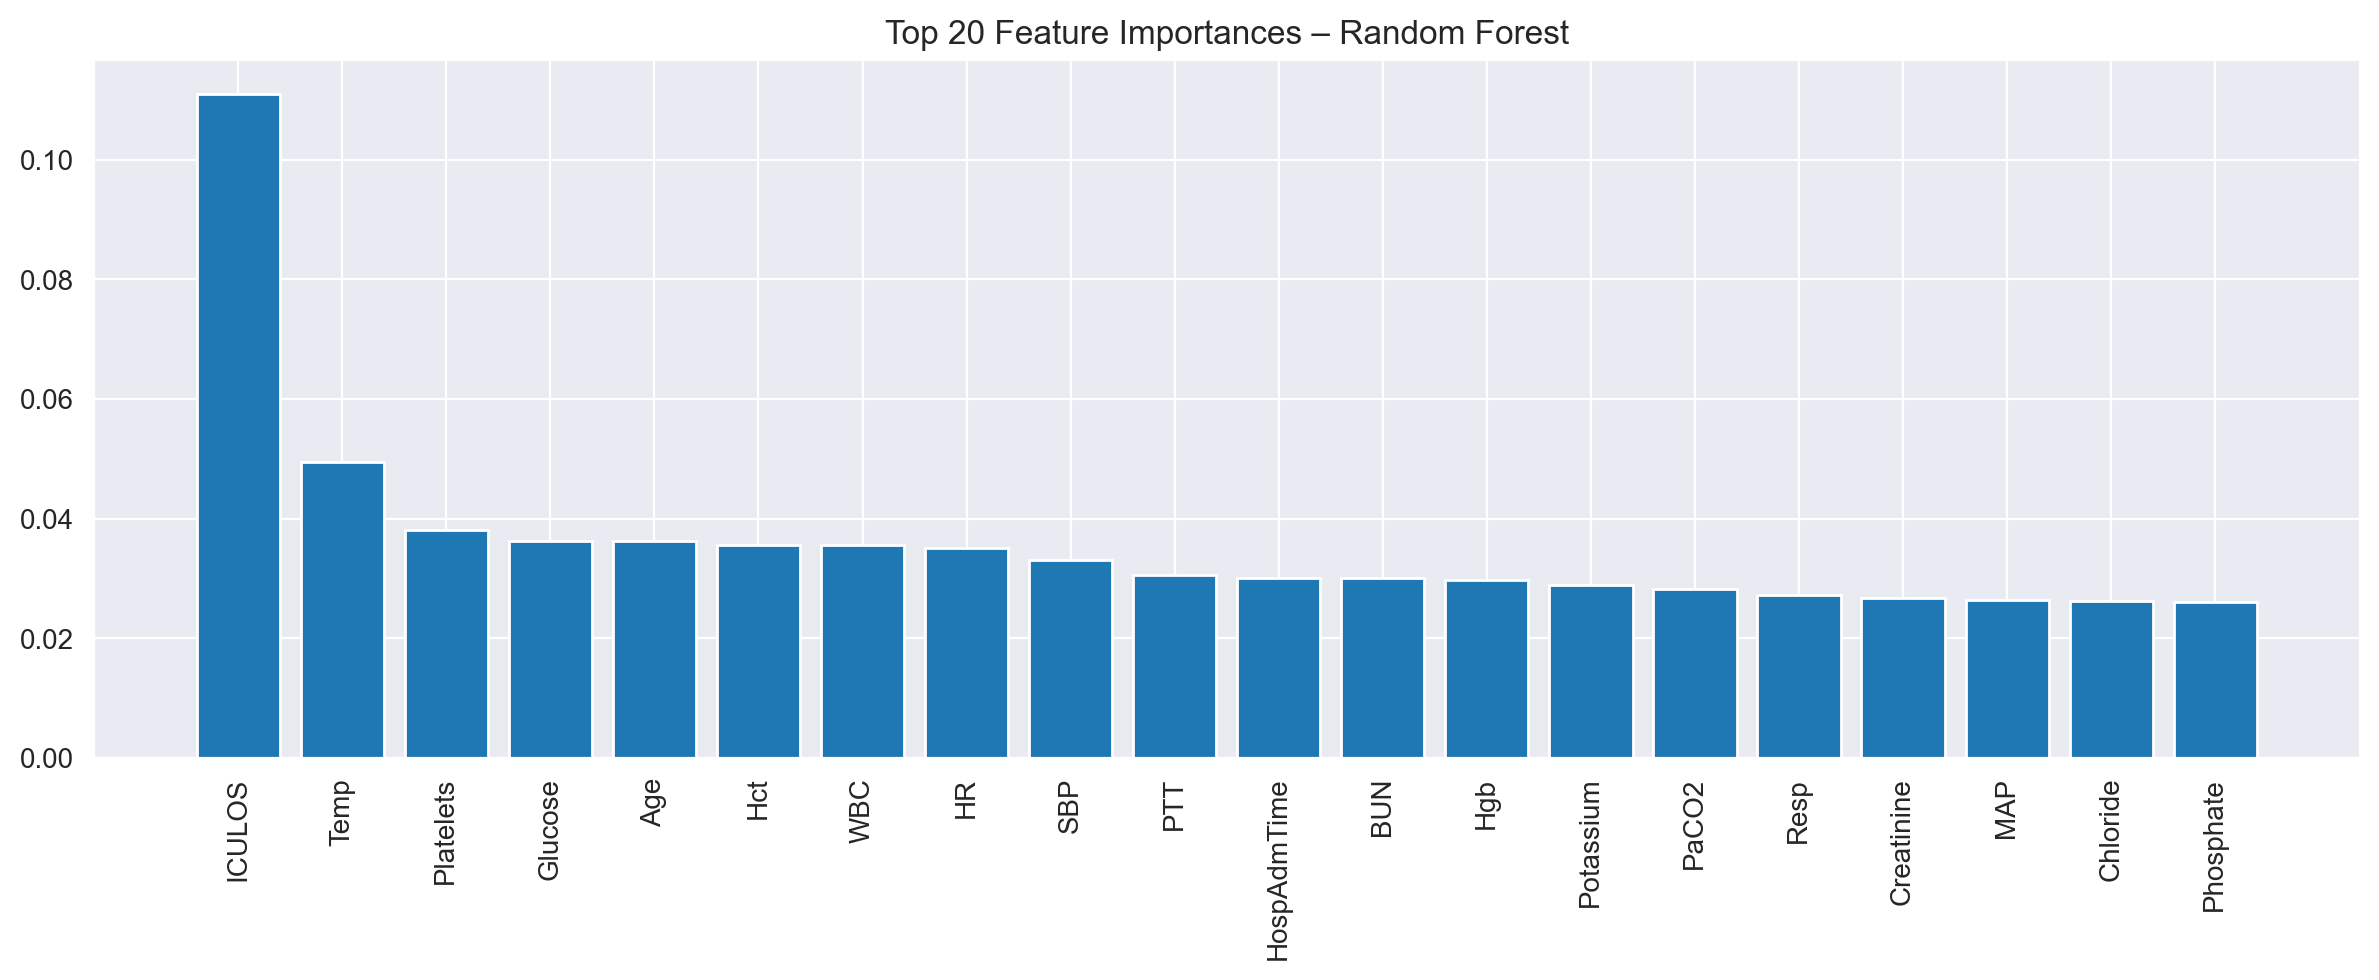

Top 4 most significant features:
  1. ICULOS
  2. Temp
  3. Platelets
  4. Glucose


In [28]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = list(train_df.columns[:-2])

plt.figure(figsize=(12, 5))
plt.title("Top 20 Feature Importances – Random Forest")
plt.bar(range(20), importances[indices[:20]])
plt.xticks(range(20), [feature_names[i] for i in indices[:20]], rotation=90)
plt.tight_layout()
plt.show()

print("Top 4 most significant features:")
for k in range(4):
    print(f"  {k+1}. {feature_names[indices[k]]}")

### Hyperparameter Tuning
Use `GridSearchCV` to find optimal hyperparameters.

In [29]:
from sklearn.ensemble import RandomForestClassifier

model_tune = RandomForestClassifier(random_state=42, n_jobs=-1)

hyperparameters = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [None, 10, 20],
    'min_samples_split': [2, 5],
}

In [30]:
CLF_PATH        = DataPath + "rf_tuning_clf.joblib"
BEST_MODEL_PATH = DataPath + "rf_tuning_best_model.joblib"

try:
    if not all(os.path.exists(p) for p in [CLF_PATH, BEST_MODEL_PATH]):
        raise FileNotFoundError("One or more joblib files missing")
    clf        = joblib.load(CLF_PATH)
    best_model = joblib.load(BEST_MODEL_PATH)
    print("Loaded clf and best model from joblib files")
except Exception as e:
    print(e)
    print("Error opening files, creating new...")
    clf        = GridSearchCV(model_tune, hyperparameters, cv=5, verbose=2, n_jobs=-1)
    best_model = clf.fit(Xtr, ytr)
    joblib.dump(clf,        CLF_PATH)
    joblib.dump(best_model, BEST_MODEL_PATH)
    print("Saved clf and best model to joblib files")

Loaded clf and best model from joblib files


In [31]:
print(type(clf))

<class 'sklearn.model_selection._search.GridSearchCV'>


In [32]:
best_model.best_params_

{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

### Test Data Prediction and Performance

In [33]:
# Predict on test set
yhat_ts      = best_model.predict(Xts)
yhat_probas  = best_model.predict_proba(Xts)[:, 1]

acc_ts = np.mean(yhat_ts == yts)
print('Accuracy on the test data is {0:f}'.format(acc_ts))

Accuracy on the test data is 0.976992


Plot ROC and PR curves.

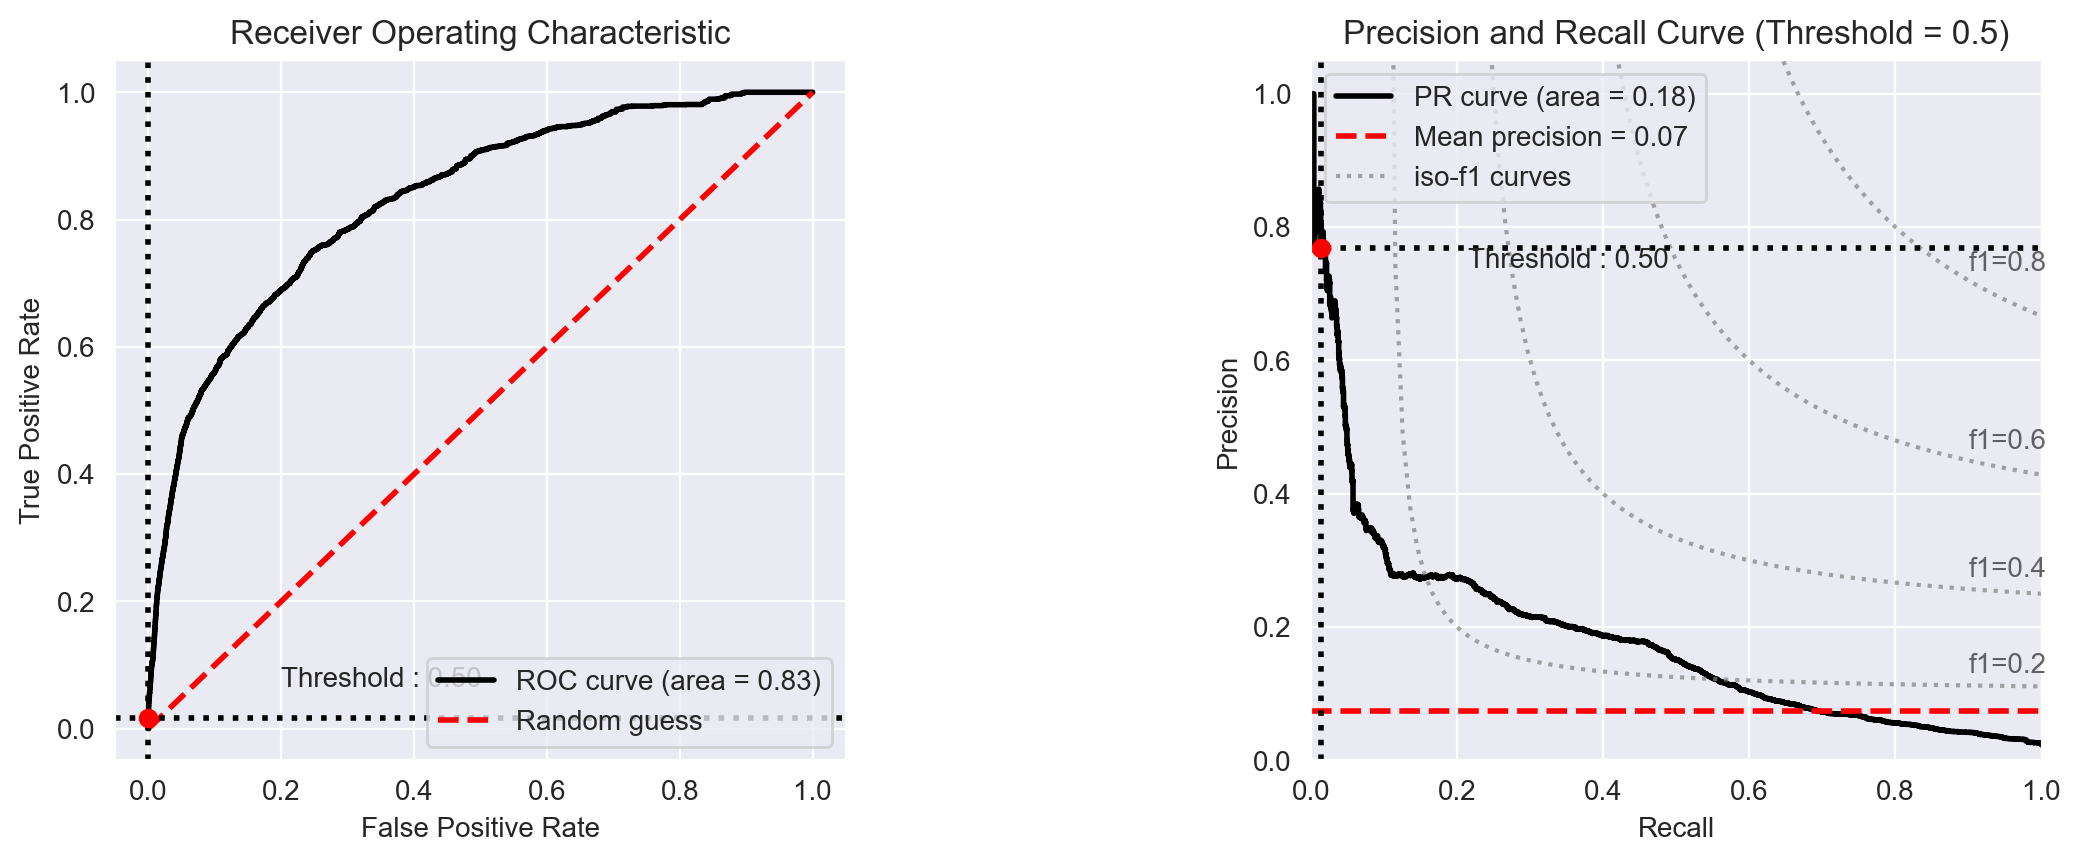

In [34]:
from plot_metric.functions import BinaryClassification
bc = BinaryClassification(yts, yhat_probas, labels=["nonSepsis", "Sepsis"])

plt.figure(figsize=(15, 10))
plt.subplot2grid(shape=(2, 6), loc=(0, 0), colspan=2)
bc.plot_roc_curve()
plt.subplot2grid((2, 6), (0, 3), colspan=2)
bc.plot_precision_recall_curve()
plt.show()

Classification report.

In [35]:
precision, recall, _ = precision_recall_curve(yts, yhat_probas)
fpr, tpr, _          = roc_curve(yts, yhat_probas)

print('f1 score  {0:.4f}:'.format(F(1, np.mean(precision), np.mean(recall))))
print('f2 score  {0:.4f}:'.format(F(2, np.mean(precision), np.mean(recall))))
print('precision {0:.4f}:'.format(precision_score(yts, yhat_ts)))
print('recall    {0:.4f}:'.format(recall_score(yts, yhat_ts)))
print('AUPRC     {0:.4f}:'.format(auc(recall, precision)))
print('AUROC     {0:.4f}:'.format(auc(fpr, tpr)))
print('Acc       {0:.4f}:'.format(accuracy_score(yts, yhat_ts)))

bc.print_report()

f1 score  0.1350:
f2 score  0.2680:
precision 0.7692:
recall    0.0145:
AUPRC     0.1801:
AUROC     0.8310:
Acc       0.9770:
                   ________________________
                  |  Classification Report |
                   ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
              precision    recall  f1-score   support

   nonSepsis       0.98      1.00      0.99    115852
      Sepsis       0.77      0.01      0.03      2757

    accuracy                           0.98    118609
   macro avg       0.87      0.51      0.51    118609
weighted avg       0.97      0.98      0.97    118609



In [36]:
record_result('Random Forest', yts, yhat_ts, yhat_probas, fitted_model=best_model, fitted_scaler=scaler)

{'model': 'Random Forest',
 'accuracy': 0.9769916279540338,
 'precision': 0.7692307692307693,
 'recall': 0.014508523757707652,
 'f1': 0.028479886080455676,
 'f2': 0.018050541516245484,
 'auroc': 0.8309909171947534,
 'auprc': 0.18006156750400432}

## SVM Classification for Sepsis
Separate features (X) and labels (y), then fit the model on training data.

In [37]:
Xtr,  ytr  = predictors_labels_allocator(train_df)
Xvld, yvld = predictors_labels_allocator(valid_df)
Xts,  yts  = predictors_labels_allocator(test_df)

Define and fit a `StandardScaler` on training data.

In [38]:
scaler = preprocessing.StandardScaler()
scaler.fit(Xtr)
Xtr  = scaler.transform(Xtr)
Xvld = scaler.transform(Xvld)
Xts  = scaler.transform(Xts)

Create a `SVM` model and fit on training data.

In [39]:
MODEL_PATH = DataPath + "svm_baseline_model.joblib"

try:
    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError("Model file not found")
    model = joblib.load(MODEL_PATH)
    print("Loaded model from disk")

except Exception as e:
    print(e)
    print("Training new model...")
    model = LinearSVC(C=1.0, random_state=42, class_weight='balanced')
    model.fit(Xtr, ytr)
    joblib.dump(model, MODEL_PATH)
    print(f"Model saved to {MODEL_PATH}")

Loaded model from disk


Measure validation accuracy.

In [40]:
yhat = model.predict(Xvld)
acc = np.mean(yhat == yvld)
print('Accuracy on the validation data is {0:f}'.format(acc))

Accuracy on the validation data is 0.772614


### Feature Importance

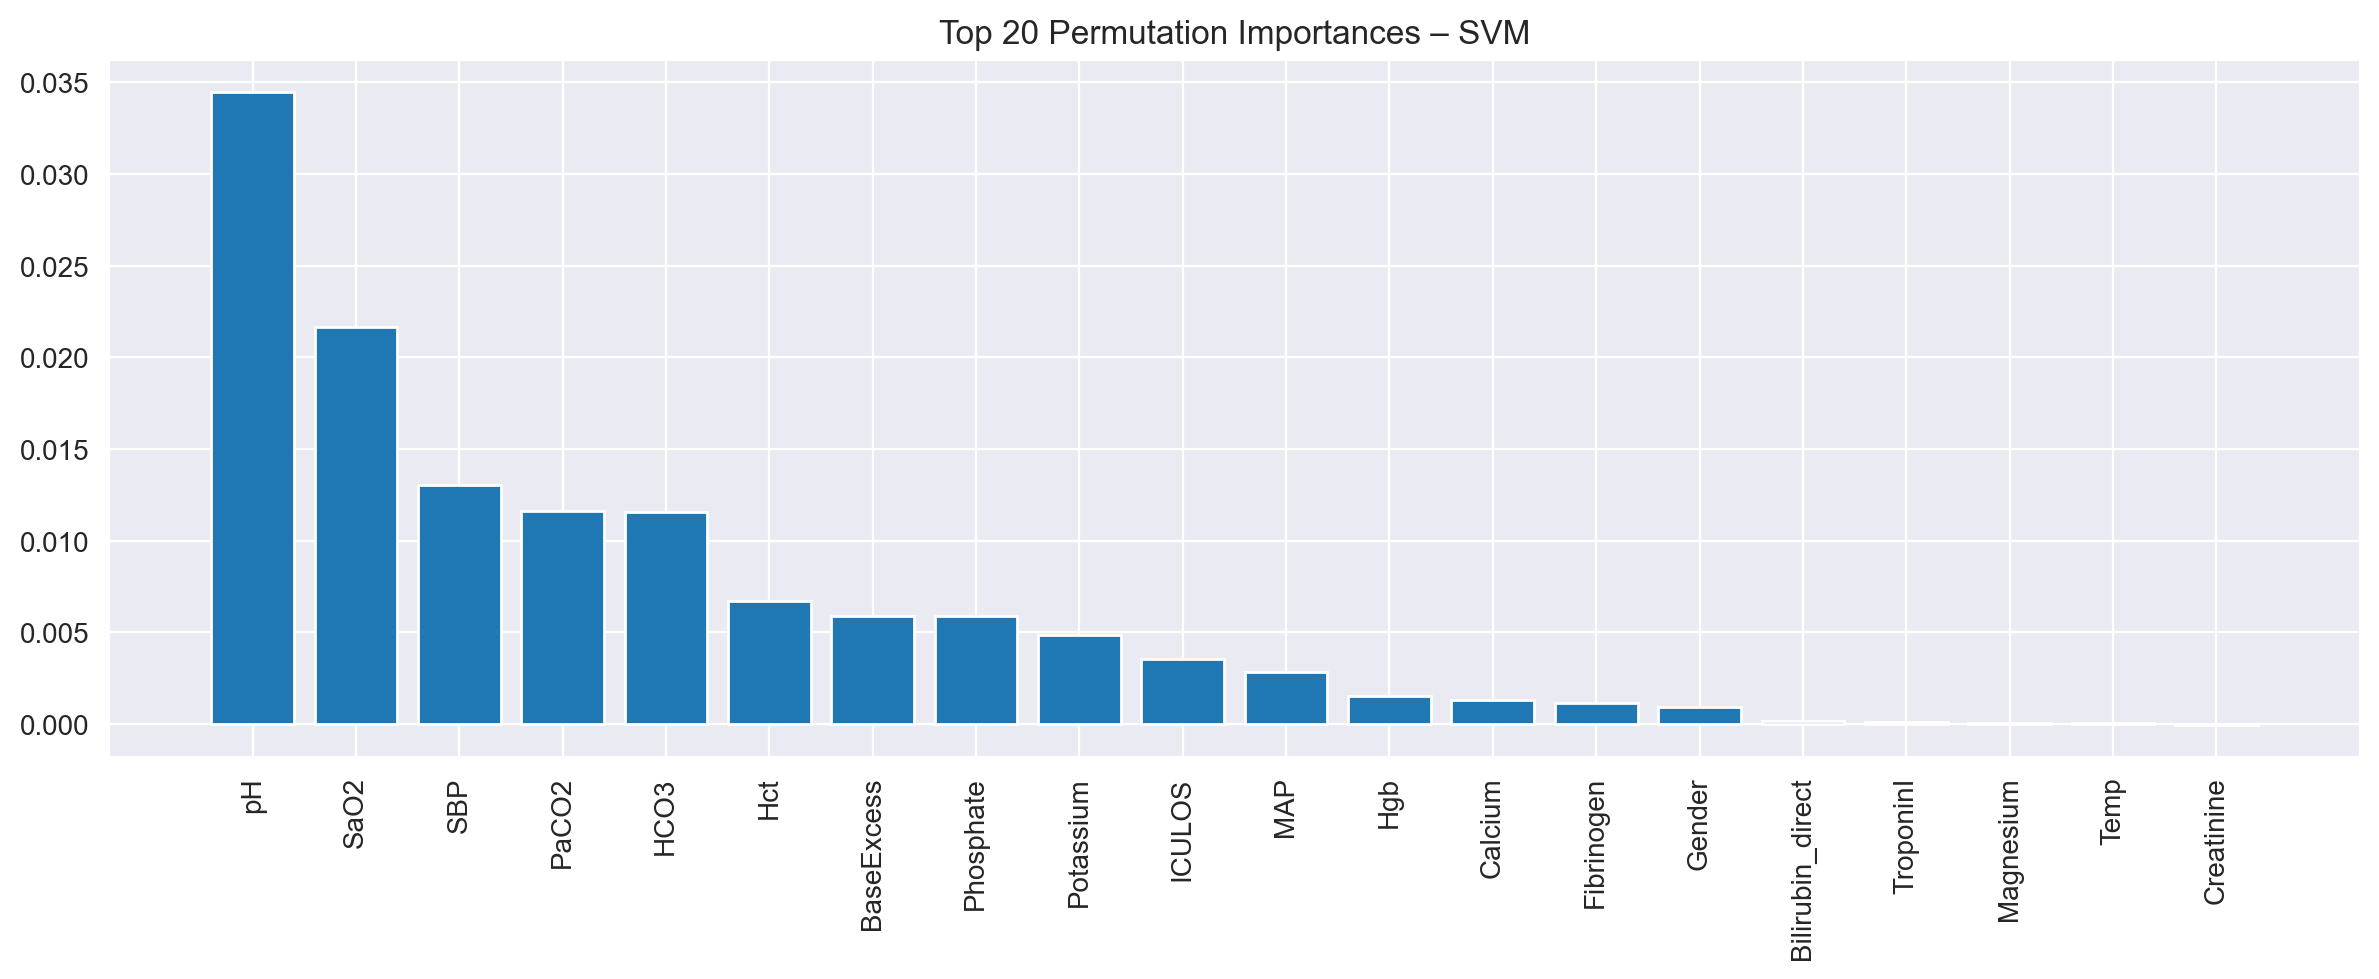

Top 4 most significant features:
  1. pH
  2. SaO2
  3. SBP
  4. PaCO2


In [41]:
# SVM does not provide feature importances directly.
# We approximate importance via the absolute values of the decision function coefficients
# (only available for linear kernel). For RBF we show a permutation-importance proxy.
from sklearn.inspection import permutation_importance

result = permutation_importance(model, Xvld, yvld, n_repeats=10, random_state=42, n_jobs=-1)
feature_names = list(train_df.columns[:-2])
indices = np.argsort(result.importances_mean)[::-1]

plt.figure(figsize=(12, 5))
plt.title("Top 20 Permutation Importances – SVM")
plt.bar(range(20), result.importances_mean[indices[:20]])
plt.xticks(range(20), [feature_names[i] for i in indices[:20]], rotation=90)
plt.tight_layout()
plt.show()

print("Top 4 most significant features:")
for k in range(4):
    print(f"  {k+1}. {feature_names[indices[k]]}")

### Hyperparameter Tuning
Use `GridSearchCV` to find optimal hyperparameters.

In [42]:
from sklearn.svm import SVC

model_tune = SVC(probability=True, random_state=42)

hyperparameters = {
    'C':      [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma':  ['scale', 'auto'],
}

In [43]:
print(Xtr.shape)

(552839, 37)


In [44]:
from sklearn.utils import resample

MAX_SAMPLES = 5000000

CLF_PATH        = DataPath + "svm_tuning_clf.joblib"
BEST_MODEL_PATH = DataPath + "svm_tuning_best_model.joblib"
FINAL_MODEL_PATH = DataPath + "svm_final_model.joblib"

try:
    if not all(os.path.exists(p) for p in [CLF_PATH, BEST_MODEL_PATH, FINAL_MODEL_PATH]):
        raise FileNotFoundError("One or more joblib files missing")
    clf         = joblib.load(CLF_PATH)
    best_model  = joblib.load(BEST_MODEL_PATH)
    final_model = joblib.load(FINAL_MODEL_PATH)
    print("Loaded clf, best model, and final model from joblib files")

except Exception as e:
    print(e)
    print("Error opening files, creating new...")

    # Subsample for grid search
    
    if len(Xtr) > MAX_SAMPLES:
        Xtr_sub, ytr_sub = resample(Xtr, ytr, n_samples=MAX_SAMPLES,
                                     stratify=ytr, random_state=42)
    else:
        Xtr_sub, ytr_sub = Xtr, ytr
        print(f"Grid search using {len(Xtr_sub)} samples instead of {len(Xtr)}")

    # Grid search on subsample
    model_tune = LinearSVC(random_state=42, class_weight='balanced')
    hyperparameters = {
        'C':     [0.1, 1, 10],
        #'gamma': ['scale', 'auto'],
    }
    clf        = GridSearchCV(model_tune, hyperparameters, cv=3, verbose=1,
                              n_jobs=-1, scoring='roc_auc')
    best_model = clf.fit(Xtr_sub, ytr_sub)
    print("Best params:", best_model.best_params_)

    # Retrain best params on full training data
    final_model = LinearSVC(**best_model.best_params_,
                      random_state=42, class_weight='balanced')
    final_model.fit(Xtr, ytr)
    print("Retrained final model on full training data")

    # Save all three
    joblib.dump(clf,         CLF_PATH)
    joblib.dump(best_model,  BEST_MODEL_PATH)
    joblib.dump(final_model, FINAL_MODEL_PATH)
    print("Saved clf, best model, and final model to joblib files")

Loaded clf, best model, and final model from joblib files


In [45]:
print(type(clf))

<class 'sklearn.model_selection._search.GridSearchCV'>


In [46]:
best_model.best_params_

{'C': 0.1}

### Test Data Prediction and Performance

In [47]:
from sklearn.calibration import CalibratedClassifierCV

# Wrap the already-trained final_model
calibrated_model = CalibratedClassifierCV(final_model, cv="prefit")
calibrated_model.fit(Xvld, yvld)  # fits the calibration on validation data

# Now use calibrated_model for probabilities
yhat_ts     = final_model.predict(Xts)          # keep using final_model for labels
yhat_probas = calibrated_model.predict_proba(Xts)[:, 1]  # use calibrated for probas

acc_ts = np.mean(yhat_ts == yts)
print('Accuracy on the test data is {0:f}'.format(acc_ts))

Accuracy on the test data is 0.772724


c:\Users\calab\anaconda3\envs\TensorFlow\lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Plot ROC and PR curves.

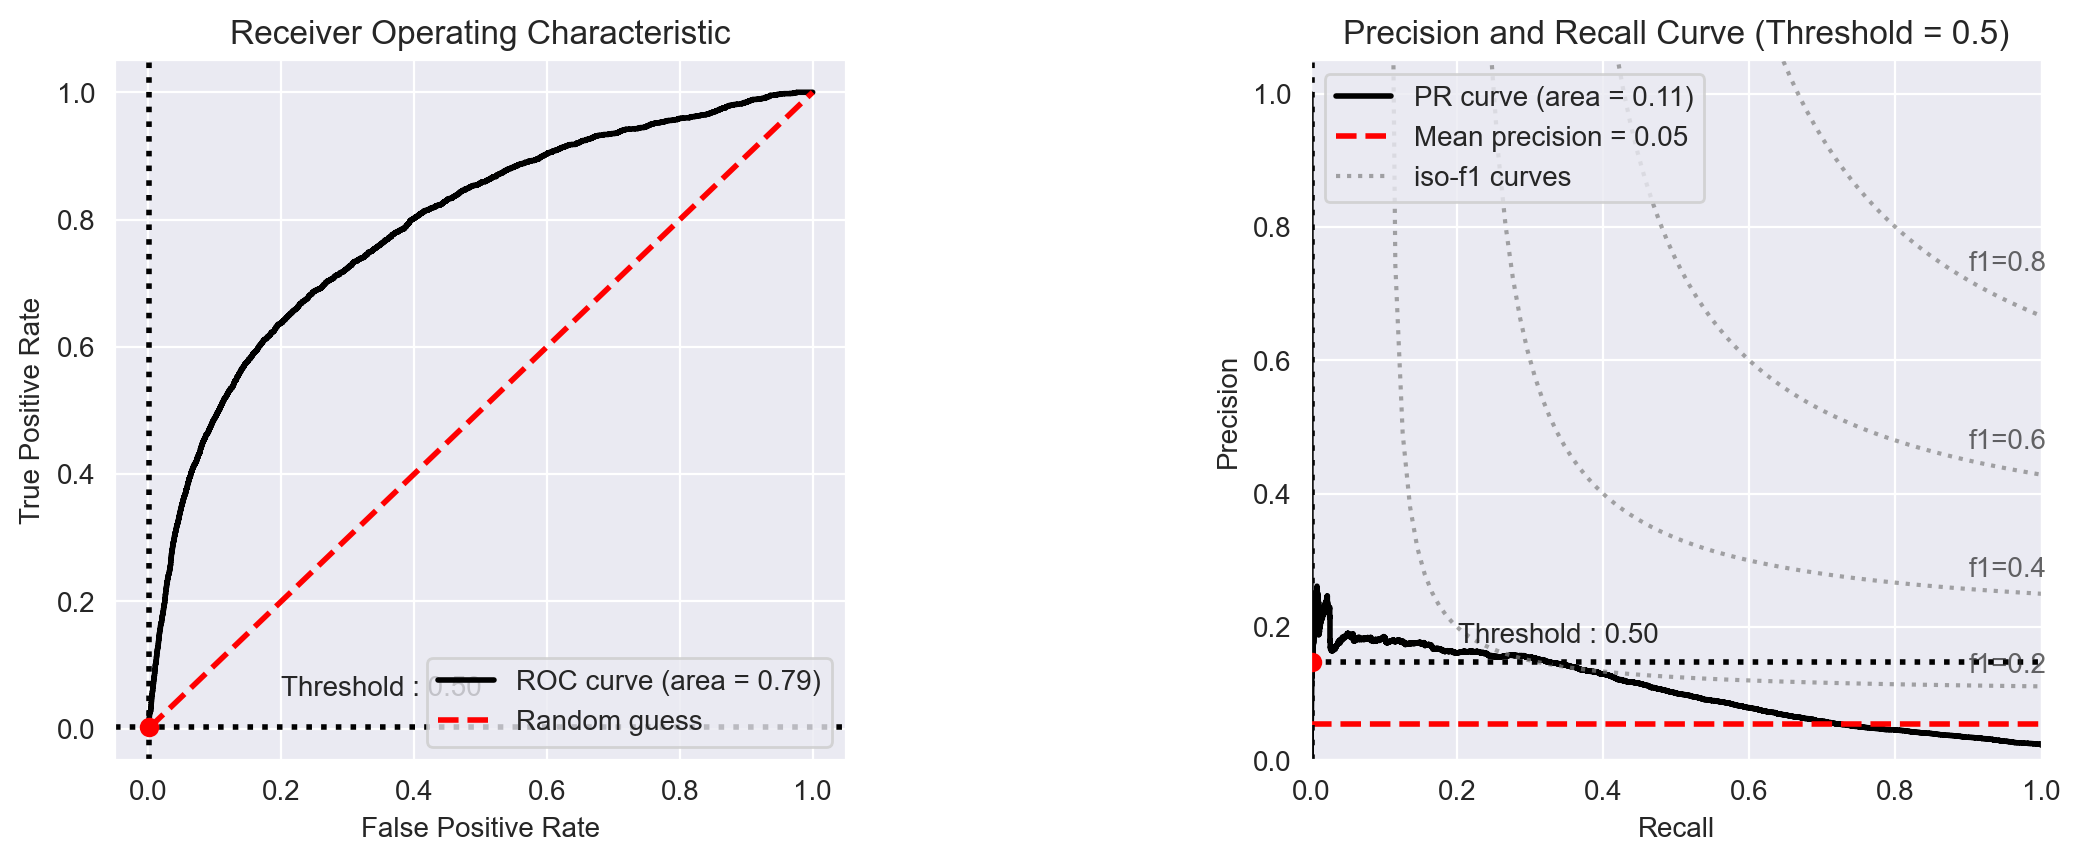

In [48]:
from plot_metric.functions import BinaryClassification
bc = BinaryClassification(yts, yhat_probas, labels=["nonSepsis", "Sepsis"])

plt.figure(figsize=(15, 10))
plt.subplot2grid(shape=(2, 6), loc=(0, 0), colspan=2)
bc.plot_roc_curve()
plt.subplot2grid((2, 6), (0, 3), colspan=2)
bc.plot_precision_recall_curve()
plt.show()

Classification report.

In [49]:
precision, recall, _ = precision_recall_curve(yts, yhat_probas)
fpr, tpr, _          = roc_curve(yts, yhat_probas)

print('f1 score  {0:.4f}:'.format(F(1, np.mean(precision), np.mean(recall))))
print('f2 score  {0:.4f}:'.format(F(2, np.mean(precision), np.mean(recall))))
print('precision {0:.4f}:'.format(precision_score(yts, yhat_ts)))
print('recall    {0:.4f}:'.format(recall_score(yts, yhat_ts)))
print('AUPRC     {0:.4f}:'.format(auc(recall, precision)))
print('AUROC     {0:.4f}:'.format(auc(fpr, tpr)))
print('Acc       {0:.4f}:'.format(accuracy_score(yts, yhat_ts)))

bc.print_report()

f1 score  0.1017:
f2 score  0.2126:
precision 0.0655:
recall    0.6620:
AUPRC     0.1056:
AUROC     0.7877:
Acc       0.7727:
                   ________________________
                  |  Classification Report |
                   ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
              precision    recall  f1-score   support

   nonSepsis       0.98      1.00      0.99    115852
      Sepsis       0.15      0.00      0.00      2757

    accuracy                           0.98    118609
   macro avg       0.56      0.50      0.50    118609
weighted avg       0.96      0.98      0.97    118609



In [50]:
record_result('Linear SVM', yts, yhat_ts, yhat_probas, fitted_model=calibrated_model, fitted_scaler=scaler)

{'model': 'Linear SVM',
 'accuracy': 0.7727238236558777,
 'precision': 0.06552962298025135,
 'recall': 0.6619513964454117,
 'f1': 0.1192537654784853,
 'f2': 0.23470857554400945,
 'auroc': 0.7876567649611261,
 'auprc': 0.10559315069999903}

## XGBoost Classification for Sepsis
Separate features (X) and labels (y), then fit the model on training data.

In [51]:
Xtr,  ytr  = predictors_labels_allocator(train_df)
Xvld, yvld = predictors_labels_allocator(valid_df)
Xts,  yts  = predictors_labels_allocator(test_df)

Define and fit a `StandardScaler` on training data.

In [52]:
scaler = preprocessing.StandardScaler()
scaler.fit(Xtr)
Xtr  = scaler.transform(Xtr)
Xvld = scaler.transform(Xvld)
Xts  = scaler.transform(Xts)

Create a `XGBoost` model and fit on training data.

In [53]:
model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42,
                      use_label_encoder=False, eval_metric='logloss', n_jobs=-1)
model.fit(Xtr, ytr, eval_set=[(Xvld, yvld)], verbose=False)

c:\Users\calab\anaconda3\envs\TensorFlow\lib\site-packages\xgboost\training.py:200: UserWarning: [09:26:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


Measure validation accuracy.

In [54]:
yhat = model.predict(Xvld)
acc = np.mean(yhat == yvld)
print('Accuracy on the validation data is {0:f}'.format(acc))

Accuracy on the validation data is 0.976584


### Feature Importance

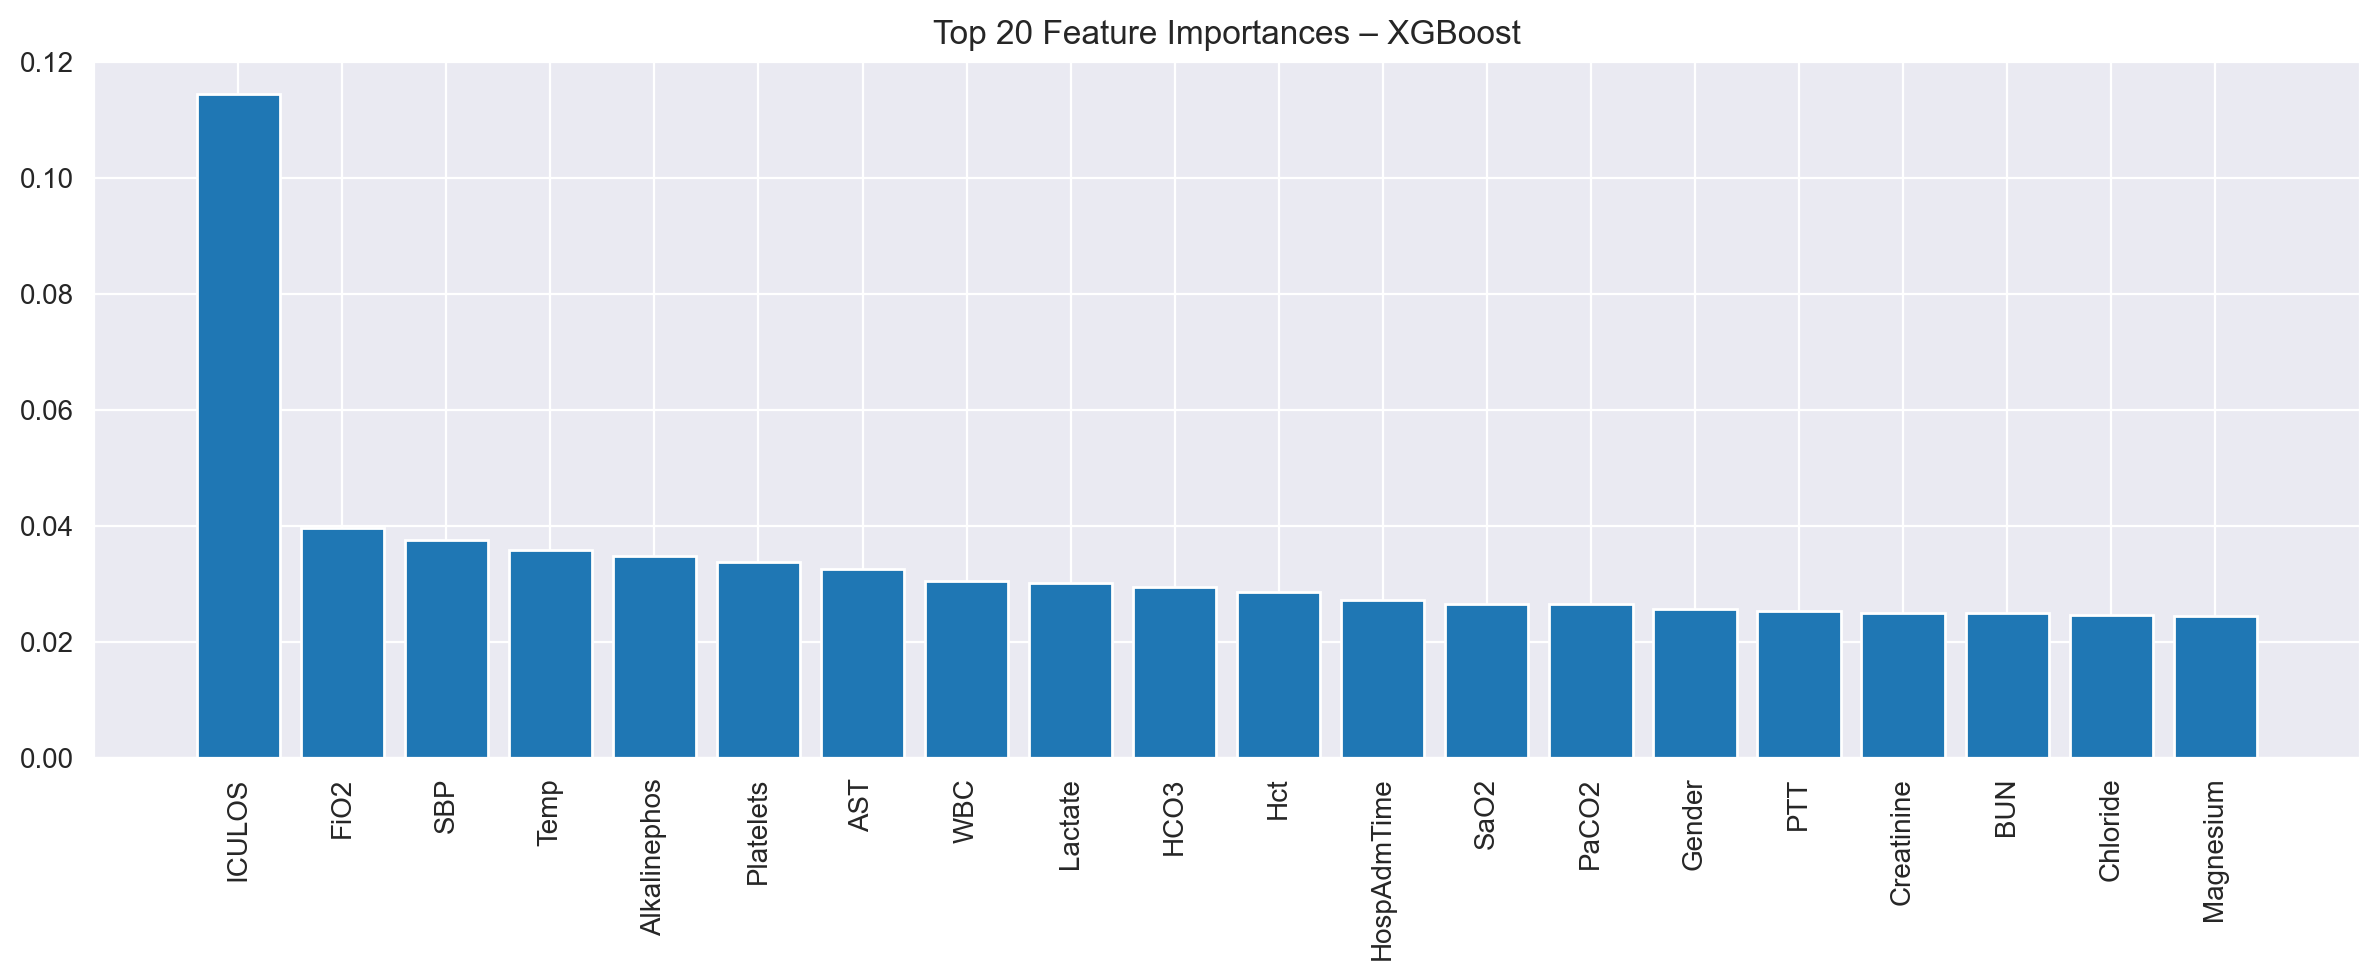

Top 4 most significant features:
  1. ICULOS
  2. FiO2
  3. SBP
  4. Temp


In [55]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = list(train_df.columns[:-2])

plt.figure(figsize=(12, 5))
plt.title("Top 20 Feature Importances – XGBoost")
plt.bar(range(20), importances[indices[:20]])
plt.xticks(range(20), [feature_names[i] for i in indices[:20]], rotation=90)
plt.tight_layout()
plt.show()

print("Top 4 most significant features:")
for k in range(4):
    print(f"  {k+1}. {feature_names[indices[k]]}")

### Hyperparameter Tuning
Use `GridSearchCV` to find optimal hyperparameters.

In [56]:
from xgboost import XGBClassifier

model_tune = XGBClassifier(random_state=42, use_label_encoder=False,
                           eval_metric='logloss', n_jobs=-1)

hyperparameters = {
    'n_estimators':  [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth':     [3, 6, 9],
}

In [57]:
CLF_PATH        = DataPath + "xgb_tuning_clf.joblib"
BEST_MODEL_PATH = DataPath + "xgb_tuning_best_model.joblib"

try:
    if not all(os.path.exists(p) for p in [CLF_PATH, BEST_MODEL_PATH]):
        raise FileNotFoundError("One or more joblib files missing")
    clf        = joblib.load(CLF_PATH)
    best_model = joblib.load(BEST_MODEL_PATH)
    print("Loaded clf and best model from joblib files")
except Exception as e:
    print(e)
    print("Error opening files, creating new...")
    clf        = GridSearchCV(model_tune, hyperparameters, cv=5, verbose=1, n_jobs=-1)
    best_model = clf.fit(Xtr, ytr)
    joblib.dump(clf,        CLF_PATH)
    joblib.dump(best_model, BEST_MODEL_PATH)
    print("Saved clf and best model to joblib files")

Loaded clf and best model from joblib files


In [58]:
print(type(clf))

<class 'sklearn.model_selection._search.GridSearchCV'>


In [59]:
best_model.best_params_

{'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 200}

### Test Data Prediction and Performance

In [60]:
# Predict on test set
yhat_ts      = best_model.predict(Xts)
yhat_probas  = best_model.predict_proba(Xts)[:, 1]

acc_ts = np.mean(yhat_ts == yts)
print('Accuracy on the test data is {0:f}'.format(acc_ts))

Accuracy on the test data is 0.976705


Plot ROC and PR curves.

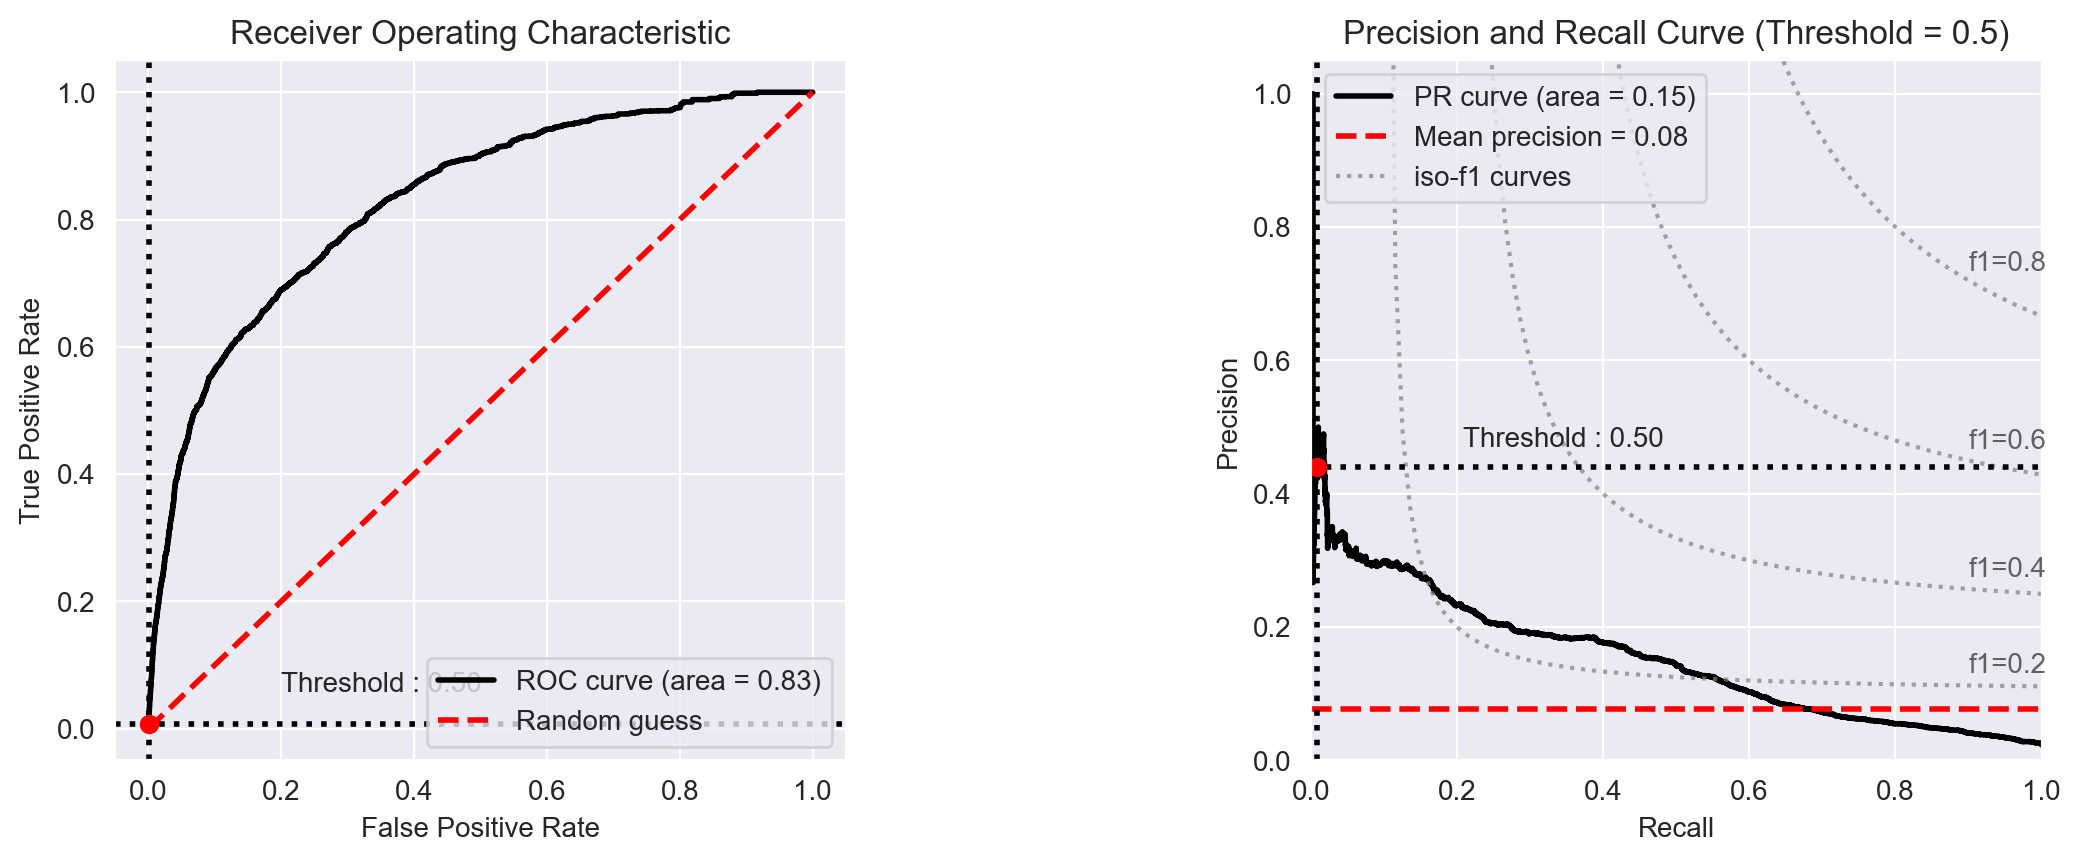

In [61]:
from plot_metric.functions import BinaryClassification
bc = BinaryClassification(yts, yhat_probas, labels=["nonSepsis", "Sepsis"])

plt.figure(figsize=(15, 10))
plt.subplot2grid(shape=(2, 6), loc=(0, 0), colspan=2)
bc.plot_roc_curve()
plt.subplot2grid((2, 6), (0, 3), colspan=2)
bc.plot_precision_recall_curve()
plt.show()

Classification report.

In [62]:
precision, recall, _ = precision_recall_curve(yts, yhat_probas)
fpr, tpr, _          = roc_curve(yts, yhat_probas)

print('f1 score  {0:.4f}:'.format(F(1, np.mean(precision), np.mean(recall))))
print('f2 score  {0:.4f}:'.format(F(2, np.mean(precision), np.mean(recall))))
print('precision {0:.4f}:'.format(precision_score(yts, yhat_ts)))
print('recall    {0:.4f}:'.format(recall_score(yts, yhat_ts)))
print('AUPRC     {0:.4f}:'.format(auc(recall, precision)))
print('AUROC     {0:.4f}:'.format(auc(fpr, tpr)))
print('Acc       {0:.4f}:'.format(accuracy_score(yts, yhat_ts)))

bc.print_report()

f1 score  0.1406:
f2 score  0.2742:
precision 0.4400:
recall    0.0080:
AUPRC     0.1535:
AUROC     0.8280:
Acc       0.9767:
                   ________________________
                  |  Classification Report |
                   ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
              precision    recall  f1-score   support

   nonSepsis       0.98      1.00      0.99    115852
      Sepsis       0.44      0.01      0.02      2757

    accuracy                           0.98    118609
   macro avg       0.71      0.50      0.50    118609
weighted avg       0.96      0.98      0.97    118609



In [63]:
record_result('XGBoost', yts, yhat_ts, yhat_probas, fitted_model=best_model, fitted_scaler=scaler)

{'model': 'XGBoost',
 'accuracy': 0.9767049717980929,
 'precision': 0.44,
 'recall': 0.00797968806673921,
 'f1': 0.015675097969362308,
 'f2': 0.009929590178732626,
 'auroc': 0.8280371138412045,
 'auprc': 0.15350375491404183}

## Results

Comparison of all four models on the held-out test set. Ranked by **AUPRC** (more informative than AUROC/accuracy under the severe class imbalance seen in this dataset — see the EDA/label-distribution check earlier in the notebook).

In [64]:
results_df = pd.DataFrame(results).set_index('model')
results_df = results_df.sort_values('auprc', ascending=False)
results_df.style.format('{:.4f}').background_gradient(cmap='Greens', axis=0)

,accuracy,precision,recall,f1,f2,auroc,auprc
model,,,,,,,
Random Forest,0.9770,0.7692,0.0145,0.0285,0.0181,0.8310,0.1801
XGBoost,0.9767,0.4400,0.0080,0.0157,0.0099,0.8280,0.1535
Logistic Regression,0.9766,0.1923,0.0018,0.0036,0.0023,0.7774,0.1112
Linear SVM,0.7727,0.0655,0.6620,0.1193,0.2347,0.7877,0.1056


In [65]:
# Baseline comparison: how much do the more complex models improve on the Logistic Regression baseline?
baseline = results_df.loc['Logistic Regression']
improvement = (results_df - baseline)
improvement[['recall', 'f2', 'auprc', 'auroc']].style.format('{:+.4f}')

,recall,f2,auprc,auroc
model,,,,
Random Forest,+0.0127,+0.0158,+0.0689,+0.0536
XGBoost,+0.0062,+0.0077,+0.0423,+0.0507
Logistic Regression,+0.0000,+0.0000,+0.0000,+0.0000
Linear SVM,+0.6601,+0.2324,-0.0056,+0.0103


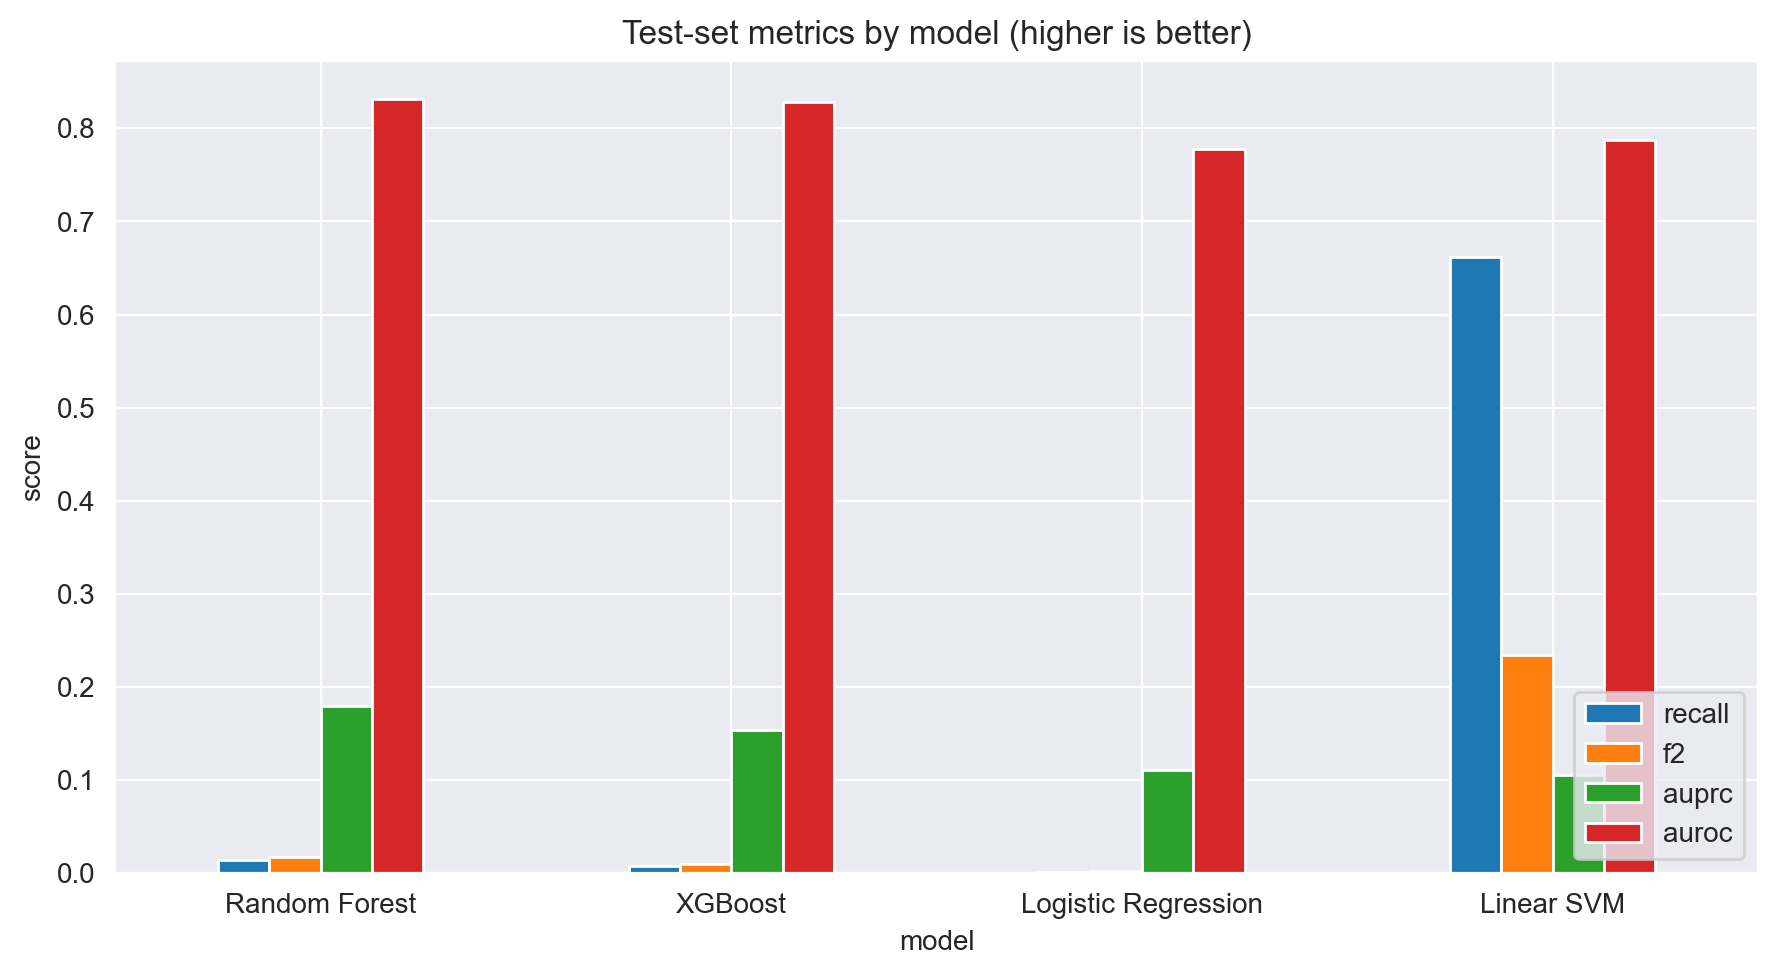

In [66]:
metrics_to_plot = ['recall', 'f2', 'auprc', 'auroc']
results_df[metrics_to_plot].plot(kind='bar', figsize=(9,5))
plt.ylabel('score')
plt.title('Test-set metrics by model (higher is better)')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Reading the results:** rank models primarily by AUPRC and recall/F2 rather than accuracy or AUROC alone, since those best reflect performance on the rare, clinically-critical positive class. Missing a true sepsis case (false negative) is far more costly than a false alarm, which is why F2 (recall-weighted) is included alongside F1.

## Interactive Detection Demo — Try It Yourself

Type in (or slide) a set of vitals/labs for a hypothetical ICU hour and see what the best-performing model predicts.

- The best model is selected automatically from `results_df` (highest AUPRC).
- Any feature you don't provide is filled in with its **training-set median**, so a partial, clinically-plausible input still works.
- Because sepsis-positive hours are rare, a plain 0.5 probability threshold rarely fires — the model's probabilities sit low even for genuine positive cases, since the base rate is low. So instead of guessing, the default threshold below is chosen to **maximise F2 on the validation set**.

In [67]:
# Pick the best model (by AUPRC) for the live demo
best_model_name = results_df.index[0]
bundle = trained_models[best_model_name]
demo_model = bundle['model']
demo_scaler = bundle['scaler']
demo_feature_names = bundle['feature_names']

feature_medians = train_df[demo_feature_names].median()

print(f"Live demo is using: {best_model_name}")
print(f"Number of input features expected: {len(demo_feature_names)}")
feature_medians

Live demo is using: Random Forest
Number of input features expected: 37


HR                   84.00
O2Sat                98.00
Temp                 36.89
SBP                 118.00
MAP                  77.00
DBP                  52.00
Resp                 18.00
BaseExcess            0.00
HCO3                 24.00
FiO2                  0.40
pH                    7.36
PaCO2                36.00
SaO2                  0.00
AST                   0.00
BUN                  17.00
Alkalinephos          0.00
Calcium               8.20
Chloride            106.00
Creatinine            0.90
Bilirubin_direct      0.00
Glucose             122.00
Lactate               0.00
Magnesium             2.00
Phosphate             3.20
Potassium             4.00
Bilirubin_total       0.00
TroponinI             0.00
Hct                  30.80
Hgb                  10.50
PTT                  28.70
WBC                  10.70
Fibrinogen            0.00
Platelets           190.00
Age                  65.23
Gender                1.00
HospAdmTime          -2.57
ICULOS               21.00
d

In [68]:
# --- Data-driven decision threshold (see explanation above) ---
Xvld_raw, yvld_raw = predictors_labels_allocator(valid_df)
Xvld_scaled = demo_scaler.transform(Xvld_raw)
vld_probas = demo_model.predict_proba(Xvld_scaled)[:, 1]

pos_probas = vld_probas[yvld_raw == 1]
neg_probas = vld_probas[yvld_raw == 0]
print(f"Predicted probability for TRUE sepsis-positive validation hours: "
      f"min={pos_probas.min():.3f}, median={np.median(pos_probas):.3f}, max={pos_probas.max():.3f}")
print(f"Predicted probability for TRUE sepsis-negative validation hours: "
      f"min={neg_probas.min():.3f}, median={np.median(neg_probas):.3f}, max={neg_probas.max():.3f}")

candidate_thresholds = np.linspace(0.01, 0.99, 99)
f2_scores = []
for t in candidate_thresholds:
    preds = (vld_probas >= t).astype(int)
    p = precision_score(yvld_raw, preds, zero_division=0)
    r = recall_score(yvld_raw, preds, zero_division=0)
    f2_scores.append(F(2, p, r) if (p > 0 or r > 0) else 0.0)

demo_threshold = float(candidate_thresholds[int(np.argmax(f2_scores))])
print(f"\nDefault demo threshold set to {demo_threshold:.3f} (maximises F2 on the validation set)")

Predicted probability for TRUE sepsis-positive validation hours: min=0.005, median=0.069, max=0.702
Predicted probability for TRUE sepsis-negative validation hours: min=0.004, median=0.012, max=0.705

Default demo threshold set to 0.080 (maximises F2 on the validation set)


In [69]:
def predict_sepsis_risk(record: dict, threshold: float = None, verbose: bool = True):
    """
    Run the trained pipeline's best model on a single hand-entered ICU-hour record.

    @param record: dict of {feature_name: value}. Any feature not supplied is filled with
                    the training-set median for that feature (see `feature_medians` above).
    @param threshold: probability above which we flag the record as sepsis-positive.
                       Defaults to `demo_threshold` (F2-optimal on validation data).
    @return: dict with the predicted label, predicted probability, and threshold used.
    """
    if threshold is None:
        threshold = demo_threshold

    row = feature_medians.copy()
    unknown_keys = [k for k in record if k not in demo_feature_names]
    if unknown_keys:
        raise ValueError(f"Unknown feature name(s): {unknown_keys}. "
                          f"Valid feature names are: {demo_feature_names}")
    for k, v in record.items():
        row[k] = v

    X_input = row[demo_feature_names].values.reshape(1, -1)
    X_scaled = demo_scaler.transform(X_input)

    proba = demo_model.predict_proba(X_scaled)[0, 1]
    label = int(proba >= threshold)

    if verbose:
        risk = "HIGH RISK — sepsis flagged" if label == 1 else "low risk — not flagged"
        print(f"Model: {best_model_name}")
        print(f"Predicted probability of sepsis: {proba:.3f}  (threshold = {threshold:.3f})")
        print(f"Prediction: {label}  ->  {risk}")

    return {'label': label, 'probability': proba, 'threshold': threshold}

# --- Example: a patient with signs consistent with a developing sepsis picture ---
example_record = {
    'HR': 118,          # elevated heart rate
    'Temp': 38.9,        # fever
    'Resp': 26,          # elevated respiration
    'SBP': 88,           # low blood pressure
    'MAP': 60,
    'Lactate': 3.4,      # elevated lactate
    'WBC': 15.5,         # elevated white cell count
}
_ = predict_sepsis_risk(example_record)

Model: Random Forest
Predicted probability of sepsis: 0.035  (threshold = 0.080)
Prediction: 0  ->  low risk — not flagged


# Conclusion

While Random Forest performed best overall, it still only caught ~1.4% of Sepsis cases, meaning the vast majority of the patients would go undetected. The data provided is filled with noisy data that ends up being irrelevant to the prediction and ICULOS is the dominant feature in importance according to the models, suggesting that the "hours at risk" are more important than the physiological degradation of the patients.

### Interactive input form
Run the cell below for a small widget form (vitals + a few key labs). Adjust any value and click **Predict**. Fields left at their default represent the training-set median for that feature.

In [70]:
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
except ImportError:
    import sys
    !{sys.executable} -m pip install ipywidgets --quiet
    import ipywidgets as widgets
    from IPython.display import display, clear_output

# NOTE: if you just installed ipywidgets for the first time, RESTART THE KERNEL and re-run
# the notebook from the top -- a freshly pip-installed ipywidgets often won't render/respond
# to clicks until the kernel (and sometimes the browser tab) is restarted/reloaded.
print(f"ipywidgets version: {widgets.__version__}")

form_fields = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp',
               'Lactate', 'WBC', 'Age', 'Gender', 'ICULOS']
form_fields = [f for f in form_fields if f in demo_feature_names]

sliders = {}
for f in form_fields:
    default = float(feature_medians[f])
    lo = float(min(train_df[f].quantile(0.01), default))
    hi = float(max(train_df[f].quantile(0.99), default))
    if f == 'Gender':
        sliders[f] = widgets.Dropdown(options=[('Female', 0), ('Male', 1)], value=int(default), description=f)
    else:
        sliders[f] = widgets.FloatSlider(value=default, min=lo, max=hi,
                                          step=(hi - lo) / 100 if hi > lo else 1,
                                          description=f, continuous_update=False,
                                          style={'description_width': '80px'},
                                          layout=widgets.Layout(width='400px'))

threshold_slider = widgets.FloatSlider(value=demo_threshold, min=0.01, max=0.99, step=0.01,
                                        description='threshold', style={'description_width': '80px'})
predict_button = widgets.Button(description='Predict', button_style='primary')
output_box = widgets.Output()

def on_predict_clicked(b):
    with output_box:
        clear_output()
        print("Predict button clicked - running model...")
        record = {f: s.value for f, s in sliders.items()}
        predict_sepsis_risk(record, threshold=threshold_slider.value)

predict_button.on_click(on_predict_clicked)

form = widgets.VBox([*sliders.values(), threshold_slider, predict_button, output_box])
display(form)

ipywidgets version: 8.1.8
